# Exploratory Data Analysis (EDA)
**Digital Banking Fraud Detection Project**

This notebook performs the initial data analysis on the banking transaction dataset. We will explore features, plot distributions, evaluate class imbalance, and investigate correlation patterns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load the Dataset

In [2]:
df = pd.read_csv('../Dataset/Bank_Transaction_Fraud_Detection.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (200000, 24)


,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


### General Overview of Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  str    
 1   Customer_Name            200000 non-null  str    
 2   Gender                   200000 non-null  str    
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  str    
 5   City                     200000 non-null  str    
 6   Bank_Branch              200000 non-null  str    
 7   Account_Type             200000 non-null  str    
 8   Transaction_ID           200000 non-null  str    
 9   Transaction_Date         200000 non-null  str    
 10  Transaction_Time         200000 non-null  str    
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  str    
 13  Transaction_Type         200000 non-null  str    
 14  Merchant_Catego

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values per column:
Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64



Total duplicate rows: 0


In [5]:
df.describe()

,Age,Transaction_Amount,Account_Balance,Is_Fraud
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


### Target Class Distribution

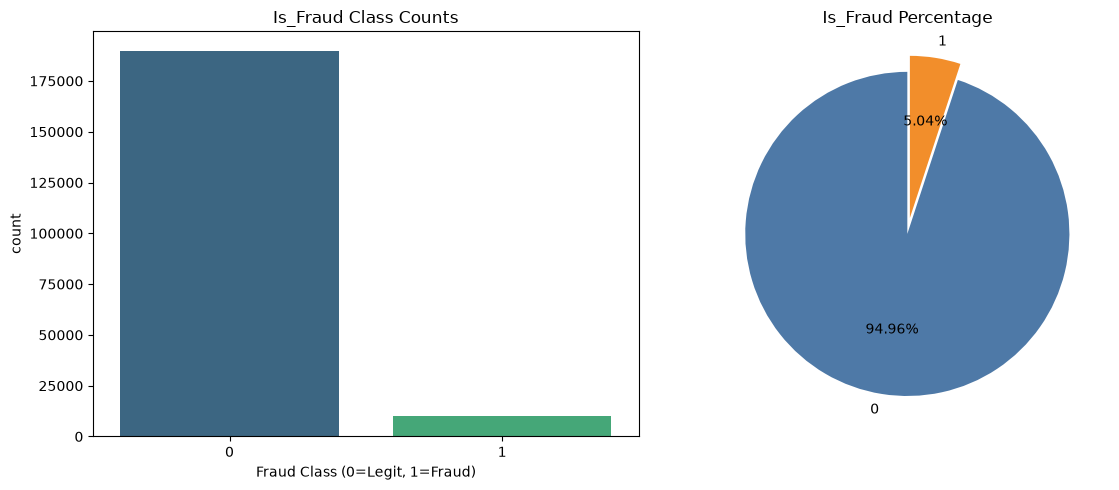

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Is_Fraud', data=df, palette='viridis')
plt.title('Is_Fraud Class Counts')
plt.xlabel('Fraud Class (0=Legit, 1=Fraud)')

plt.subplot(1, 2, 2)
df['Is_Fraud'].value_counts().plot.pie(autopct='%1.2f%%', startangle=90, colors=['#4E79A7', '#F28E2B'], explode=[0, 0.1])
plt.title('Is_Fraud Percentage')

plt.tight_layout()
plt.show()

### Numerical Feature Distributions by Fraud Class

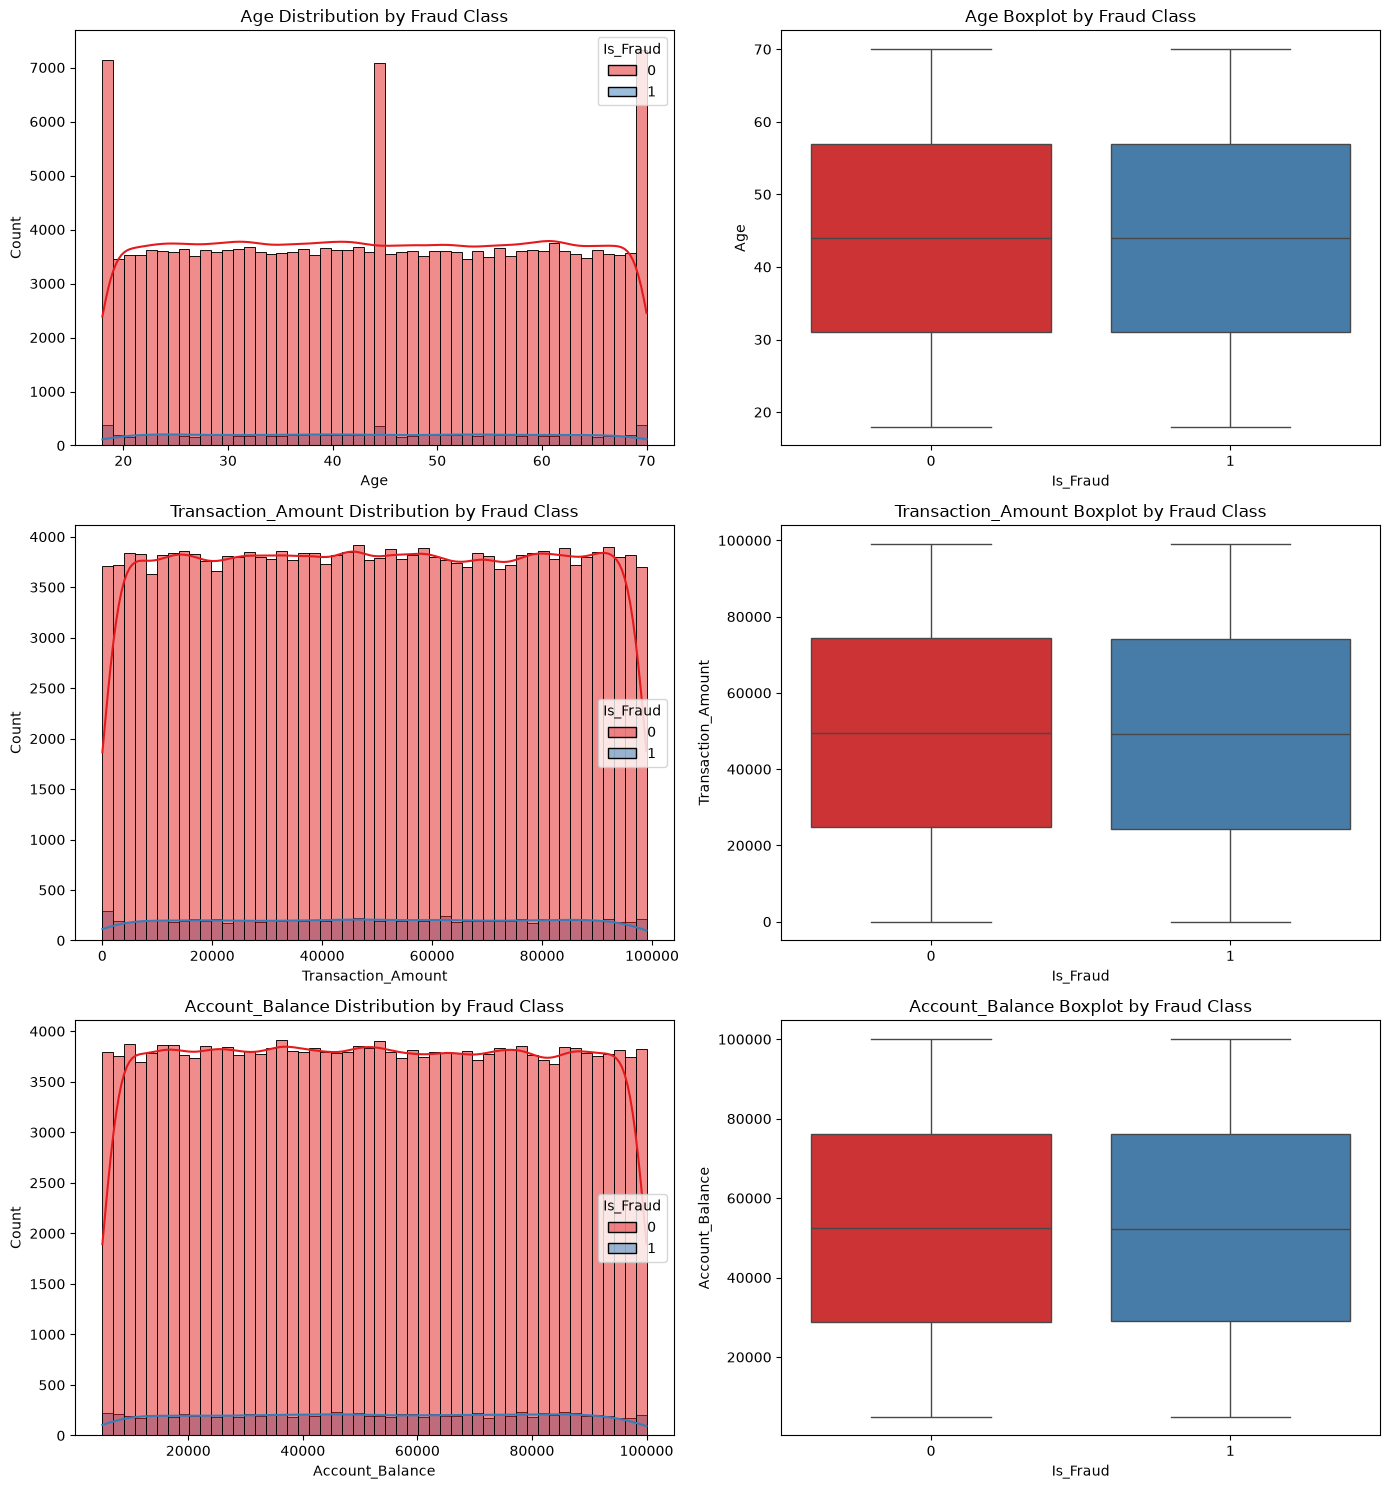

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
numeric_cols = ['Age', 'Transaction_Amount', 'Account_Balance']

for i, col in enumerate(numeric_cols):
    # KDE distributions
    sns.histplot(data=df, x=col, hue='Is_Fraud', kde=True, bins=50, ax=axes[i, 0], palette='Set1', common_norm=False)
    axes[i, 0].set_title(f'{col} Distribution by Fraud Class')
    
    # Boxplots
    sns.boxplot(data=df, x='Is_Fraud', y=col, ax=axes[i, 1], palette='Set1')
    axes[i, 1].set_title(f'{col} Boxplot by Fraud Class')

plt.tight_layout()
plt.show()

### Fraud Rate by Categorical Features

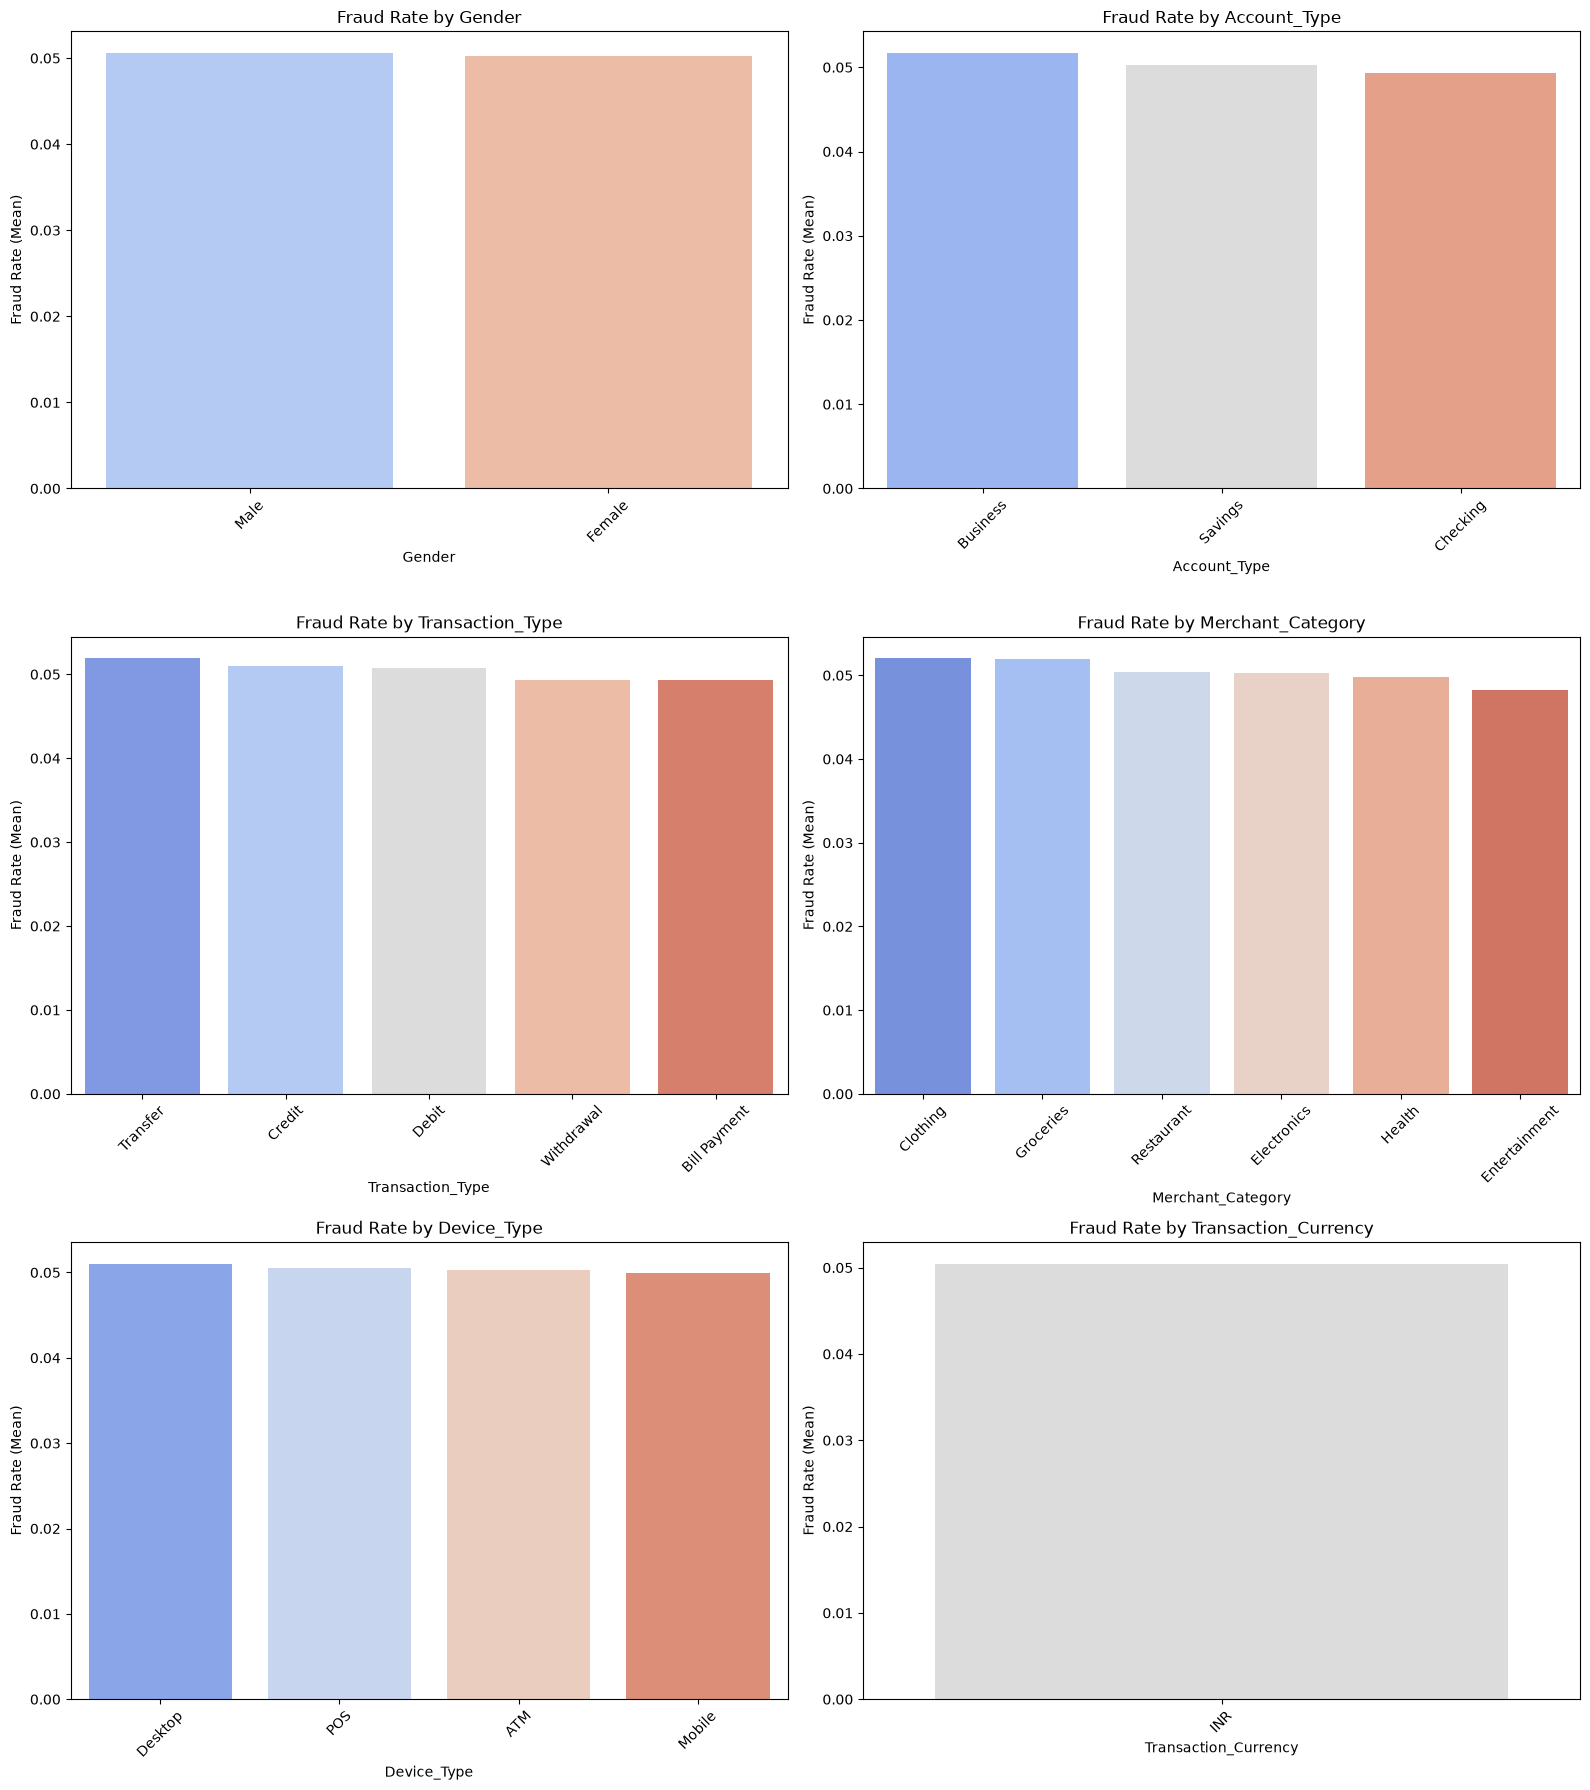

In [8]:
cat_cols = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 'Device_Type', 'Transaction_Currency']
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_rates = df.groupby(col)['Is_Fraud'].mean().reset_index().sort_values(by='Is_Fraud', ascending=False)
    sns.barplot(data=fraud_rates, x=col, y='Is_Fraud', ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate (Mean)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Time-Based Analysis

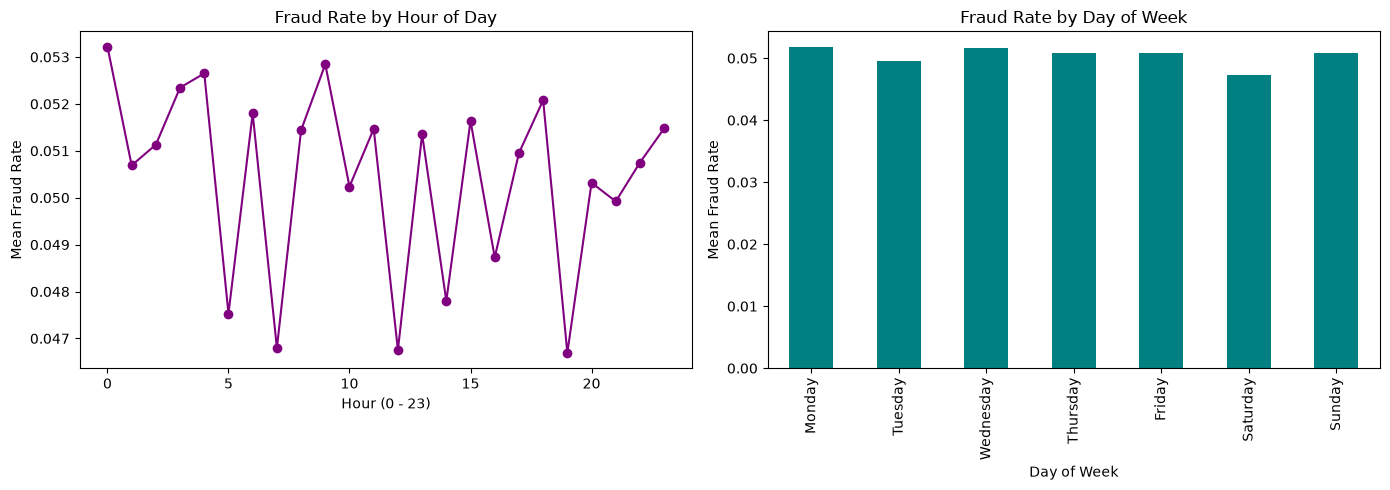

In [9]:
# Extract date/time components
df['Parsed_Date'] = pd.to_datetime(df['Transaction_Date'], format='%d-%m-%Y', errors='coerce')
df['Transaction_Hour'] = df['Transaction_Time'].str.split(':').str[0].astype(int)
df['Transaction_DayOfWeek'] = df['Parsed_Date'].dt.day_name()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df.groupby('Transaction_Hour')['Is_Fraud'].mean().plot(kind='line', marker='o', color='purple')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0 - 23)')
plt.ylabel('Mean Fraud Rate')

plt.subplot(1, 2, 2)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df.groupby('Transaction_DayOfWeek')['Is_Fraud'].mean().reindex(day_order).plot(kind='bar', color='teal')
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Mean Fraud Rate')

plt.tight_layout()
plt.show()

### Pearson Correlation Matrix

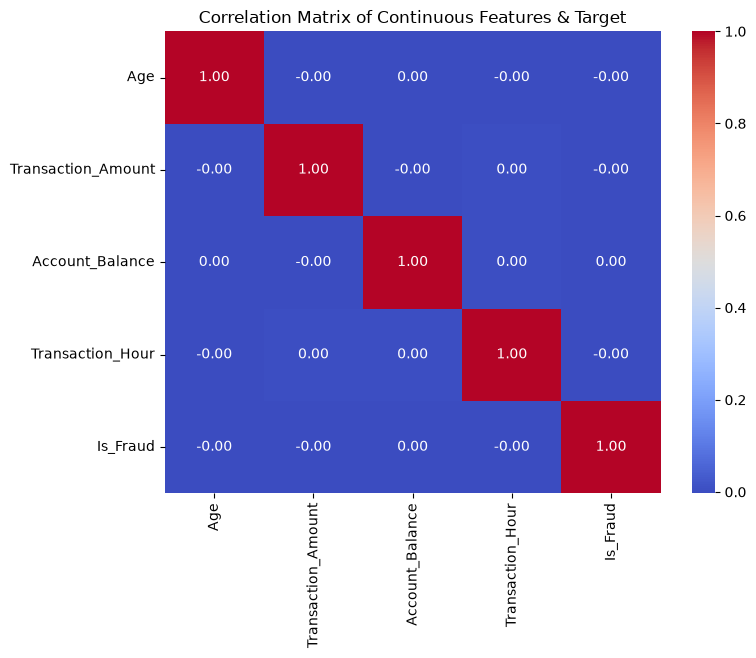

In [10]:
corr_cols = ['Age', 'Transaction_Amount', 'Account_Balance', 'Transaction_Hour', 'Is_Fraud']
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Continuous Features & Target')
plt.show()

### Key Insights Summary
1. **Class Imbalance:** The target variable `Is_Fraud` is highly imbalanced, with a ~5.04% fraud rate. Accuracy alone is not a reliable evaluation metric.
2. **Numeric Variables:** Fraudulent transactions exhibit different distributions (e.g., higher transaction amounts) compared to legitimate transactions.
3. **Categorical Features:** Certain transaction types and merchant categories show significantly higher rates of fraud than others, making encoding crucial.